# Titanic Survivors Prediction

### Problem Statement and Data Description

**Titanic Survivors Prediction**

The sinking of the Titanic is one of the most infamous shipwrecks in history.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

In this challenge, our task as a Data Scientist is to build a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc).

#### Data Dictionary

There are multiple variables in the dataset as follows:

### Loading the Dataset

In [2]:
#importing necessary library
import pandas as pd
#for plotting curves, can't work without this
%matplotlib inline
import matplotlib.pyplot as plt

In [3]:
#initializing dataframe from pandas reference to dataset file location
df = pd.read_csv(r"C:\Users\Manish Gupta\Desktop\ML Training\3. ML Life Cycle\Module 3\data.csv")

In [4]:
#Checking Dimensions of added database
df.shape

(891, 12)

In [5]:
#viewing top 5 rows in dataset
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
#printing whole dataframe
print(df)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
5              6         0       3   
6              7         0       1   
7              8         0       3   
8              9         1       3   
9             10         1       2   
10            11         1       3   
11            12         1       1   
12            13         0       3   
13            14         0       3   
14            15         0       3   
15            16         1       2   
16            17         0       3   
17            18         1       2   
18            19         0       3   
19            20         1       3   
20            21         0       2   
21            22         1       2   
22            23         1       3   
23            24         1       1   
24            25         0       3   
25          

In [6]:
#systematically printing all dataset by providing n value instead of default 5
df.head(891)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [9]:
#sub-slicing a dataframe based on conditions, here male
df[df['Sex']=='male']

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
12,13,0,3,"Saundercock, Mr. William Henry",male,20.0,0,0,A/5. 2151,8.0500,NaN,S
13,14,0,3,"Andersson, Mr. Anders Johan",male,39.0,1,5,347082,31.2750,NaN,S
16,17,0,3,"Rice, Master. Eugene",male,2.0,4,1,382652,29.1250,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
20,21,0,2,"Fynney, Mr. Joseph J",male,35.0,0,0,239865,26.0000,NaN,S


In [10]:
#mentioning all set of column namees in dataset
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [11]:
#checking types of data in columns, object is parent of string, used for classification data, while int and float for continious data
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [12]:
#Univariate Analysis - Tabular method on given dataset, central tendencies mentioned
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


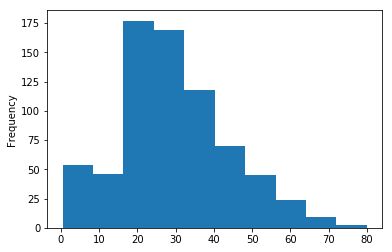

In [19]:
#Unvariate Analysis - Graphical method in gven dataset, plotting histogram and boxplot
df['Age'].plot.hist()

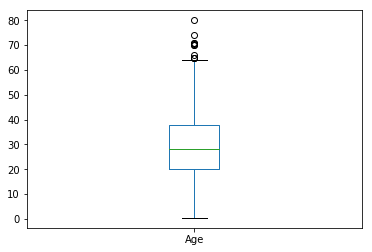

In [20]:
df['Age'].plot.box()

In [23]:
#Univariate Analysis for Categorical Data, here Sex for instance, using value_counts fun, tabular format
df['Sex'].value_counts()

male      577
female    314
Name: Sex, dtype: int64

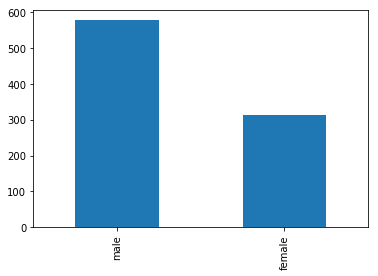

In [24]:
#Univariate Analysis for Categorical Data, here Sex for instance, using value_counts fun, graphical format
df['Sex'].value_counts().plot.bar()

In [25]:
#Univariate Analysis for Categorical Data, here Sex for instance, using value_counts fun, tabular format, percentages
df['Sex'].value_counts()*100/len(df['Sex'])

male      64.758698
female    35.241302
Name: Sex, dtype: float64

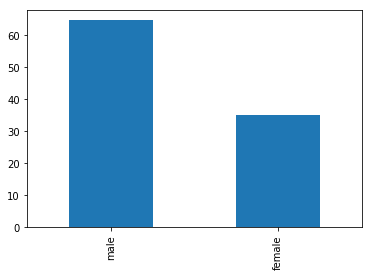

In [26]:
#Univariate Analysis for Categorical Data, here Sex for instance, using value_counts fun, graphicalr format, percentages
(df['Sex'].value_counts()*100/len(df['Sex'])).plot.bar()

# Bivariate Analysis

In [27]:
#Categorizing types of Data, Categorical or Continious
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

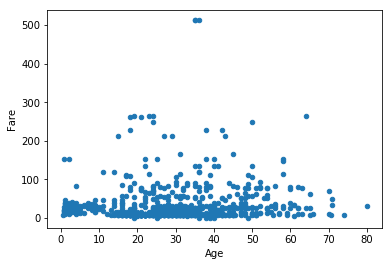

In [29]:
#BVA Type1 - Continious - Cont. BV Analysis, using Age and Fare Variables here, Graphical, using Scatter Plot
df.plot.scatter('Age', 'Fare')

In [31]:
#Chwecking Correlation between various Attributes in Dataset, 2D-Matrix Format Dataset with r values Corr. Coeff.
df.corr()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [32]:
#Determining specific Correlation Coeff between Specific Attributes, verify from above table
df['Age'].corr(df['Fare'])

0.09606669176903887

In [34]:
#BVA Type2 - Categorical - Cont. BV Analysis, using Age and Sex Variables here, Graphical, using Bar Plot
#Computing Average Age Gender wise first, using groupby method
df.groupby('Sex')['Age'].mean()

Sex
female    27.915709
male      30.726645
Name: Age, dtype: float64

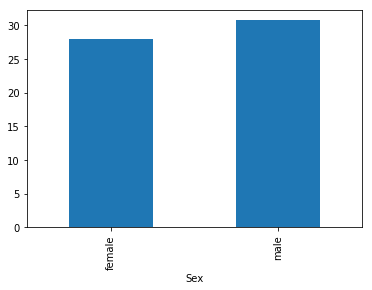

In [35]:
#Plotting Bar Graph on above data
(df.groupby('Sex')['Age'].mean()).plot.bar()

In [36]:
#Performing a 2 Sample T Test on above data to check related closeness
#importing neccessary libraries
from scipy.stats import ttest_ind

In [37]:
#Creating Arguments for T Test, sub data sets with only males and females respectively
males = df[df['Sex']=='male']

In [39]:
females = df[df['Sex']=='female']

In [40]:
#T Test in Action, result has first value as stats and other as pvalue, if pval < 0.05, accept hypo otherwise reject it
ttest_ind(males['Age'], females['Age'], nan_policy='omit')

Ttest_indResult(statistic=2.499206354920835, pvalue=0.012671296797014266)

In [41]:
#BVA Type3 - Categorical - Categ. BV Analysis, using Age and Sex Variables here, 2-Way Tabular data,
pd.crosstab(df['Sex'], df['Survived'])

Survived,0,1
Sex,,
female,81,233
male,468,109


In [43]:
#Performing a Chi-Square Test on above data to verify if ther exists any difference, hypothesis,
#importing required libraries
from scipy.stats import chi2_contingency

In [44]:
#Chi-Square Test in Action, giving 2-Way Tabular data as Input
#Result has first value as stats and other as pvalue, if pval < 0.05, accept hypo otherwise reject it
chi2_contingency(pd.crosstab(df['Sex'], df['Survived']))

(260.71702016732104,
 1.1973570627755645e-58,
 1,
 array([[ 193.47474747,  120.52525253],
        [ 355.52525253,  221.47474747]]))

# Missing Value Analysis

In [27]:
#importing necessary library
import pandas as pd
#for plotting curves, can't work without this
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np #for mean analysis

In [4]:
#initializing dataframe from pandas reference to dataset file location
df = pd.read_csv(r"C:\Users\Manish Gupta\Desktop\ML Training\3. ML Life Cycle\Module 3\data.csv")

In [6]:
#for continious data, identification of missing values done by describe, central tendencies fun
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
#for all types of data, categorical or continious, using isnull fun for MVA, false indiactes value present, true if missing
df.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
5,False,False,False,False,False,True,False,False,False,False,True,False
6,False,False,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,True,False
8,False,False,False,False,False,False,False,False,False,False,True,False
9,False,False,False,False,False,False,False,False,False,False,True,False


In [8]:
#counting total null values columnwise
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
#dropping rows with null values from dataset object, not from dataset actually, equate result to dataset for permanent changes
df.dropna().isnull().sum()      #see no null values in result finally, here view of df is changed not actual dataset

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [12]:
#see no permanent changes by above act
df.shape

(891, 12)

In [13]:
#removing rows only if all values in row are missing
df.dropna(how='all').shape  #none of such rows exist, default how is any

(891, 12)

In [14]:
#removing columns with missing values from dataset, by changing argument to drpna
df.dropna(axis=1)  #default axis is 0 for rows, and 1 here to remove columns with missing values

,PassengerId,Survived,Pclass,Name,Sex,SibSp,Parch,Ticket,Fare
0,1,0,3,"Braund, Mr. Owen Harris",male,1,0,A/5 21171,7.2500
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,1,0,PC 17599,71.2833
2,3,1,3,"Heikkinen, Miss. Laina",female,0,0,STON/O2. 3101282,7.9250
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,1,0,113803,53.1000
4,5,0,3,"Allen, Mr. William Henry",male,0,0,373450,8.0500
5,6,0,3,"Moran, Mr. James",male,0,0,330877,8.4583
6,7,0,1,"McCarthy, Mr. Timothy J",male,0,0,17463,51.8625
7,8,0,3,"Palsson, Master. Gosta Leonard",male,3,1,349909,21.0750
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,0,2,347742,11.1333
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,1,0,237736,30.0708


In [15]:
#removing columns with missing values from dataset, by changing argument to drpna
df.dropna(axis=1).shape  #default axis is 0 for rows, and 1 here to remove columns with missing values, 2 cols removed

(891, 9)

In [17]:
#removing columns with all missing values from dataset, by changing argument to drpna
df.dropna(axis=1, how='all').shape  #default axis is 0 for rows, and 1 here to remove columns with missing values, all mv col
#no such column exist in dataset with all missing values

(891, 12)

In [18]:
#replacing and filling missing values, here with 0, Imputation of MV
df.fillna(0) #missing values replaced by 0 in respective fields in dataset below use inplace=True as addit. arg for perm changes

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,0,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,0,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,0,S
5,6,0,3,"Moran, Mr. James",male,0.0,0,0,330877,8.4583,0,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,0,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,0,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,0,C


In [19]:
#replacing or Imputing Missing Values in a specific column
df['Age'].fillna(0)

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
5       0.0
6      54.0
7       2.0
8      27.0
9      14.0
10      4.0
11     58.0
12     20.0
13     39.0
14     14.0
15     55.0
16      2.0
17      0.0
18     31.0
19      0.0
20     35.0
21     34.0
22     15.0
23     28.0
24      8.0
25     38.0
26      0.0
27     19.0
28      0.0
29      0.0
       ... 
861    21.0
862    48.0
863     0.0
864    24.0
865    42.0
866    27.0
867    31.0
868     0.0
869     4.0
870    26.0
871    47.0
872    33.0
873    47.0
874    28.0
875    15.0
876    20.0
877    19.0
878     0.0
879    56.0
880    25.0
881    33.0
882    22.0
883    28.0
884    25.0
885    39.0
886    27.0
887    19.0
888     0.0
889    26.0
890    32.0
Name: Age, dtype: float64

In [20]:
#Imputing missing values with mean of available values in that specific column
df['Age'].fillna(df['Age'].mean())

0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
5      29.699118
6      54.000000
7       2.000000
8      27.000000
9      14.000000
10      4.000000
11     58.000000
12     20.000000
13     39.000000
14     14.000000
15     55.000000
16      2.000000
17     29.699118
18     31.000000
19     29.699118
20     35.000000
21     34.000000
22     15.000000
23     28.000000
24      8.000000
25     38.000000
26     29.699118
27     19.000000
28     29.699118
29     29.699118
         ...    
861    21.000000
862    48.000000
863    29.699118
864    24.000000
865    42.000000
866    27.000000
867    31.000000
868    29.699118
869     4.000000
870    26.000000
871    47.000000
872    33.000000
873    47.000000
874    28.000000
875    15.000000
876    20.000000
877    19.000000
878    29.699118
879    56.000000
880    25.000000
881    33.000000
882    22.000000
883    28.000000
884    25.000000
885    39.000000
886    27.000000
887    19.000000
888    29.6991

# Outlier Treatment

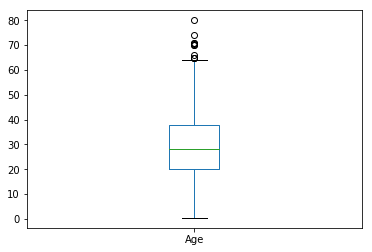

In [21]:
#Univariate Outlier Detection, here for Age Var, Boxplot, here above max val 60 line
df['Age'].plot.box()

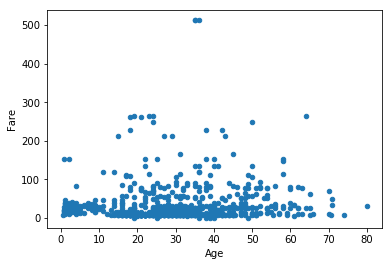

In [23]:
#Bivariate Outlier Detection, here for Age vs Fare, using Scatter, away from line of reg, here aboe 500
df.plot.scatter('Age', 'Fare')

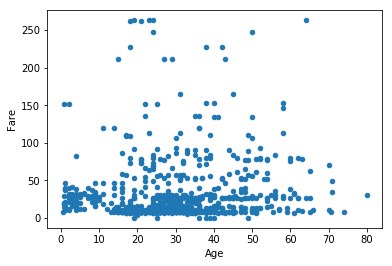

In [25]:
#Removing Outliers from dataset, here from above BV case
df[df['Fare']<300].plot.scatter('Age','Fare')   #see below, we can make permanent by equating to df

In [28]:
#Dealing with Univariate Outliers, replacing them with mean age
df.loc[df['Age']>65,'Age']=np.mean(df['Age'])

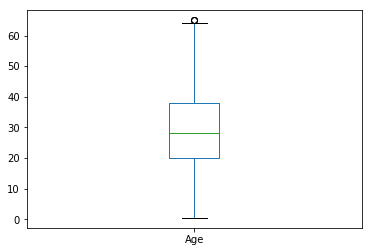

In [29]:
df['Age'].plot.box()   #see outliers removed compared to previous plot

# Variable Transformation

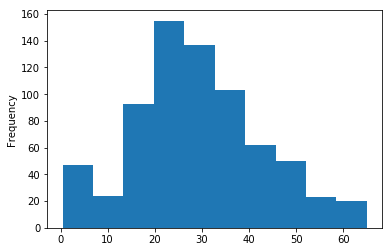

In [30]:
#Checking distribution of Age Variable
df['Age'].plot.hist()   #notice the difference on left side of graph, depicts need fot transform

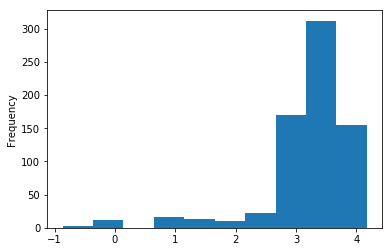

In [31]:
#transforming above using logarithmic Trans
np.log(df['Age']).plot.hist()  #notice changes after change of scale 

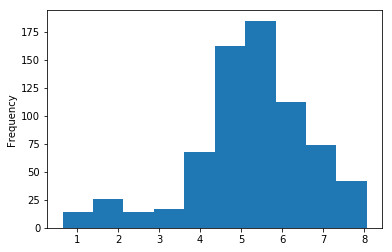

In [32]:
#transforming above using Square Root Trans
np.sqrt(df['Age']).plot.hist()  #better and more symmetric than log here, for other pow, use power and other arg as exponent

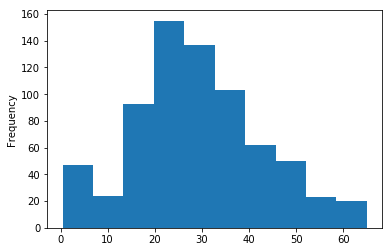

In [33]:
#Type 3 - Performing Binning - Convrting Cont. data to Categorical Data
df['Age'].plot.hist()

In [34]:
bins=[0,15,80]   #Cat 1 is 0-15, Cat 2 is 16-80, categorizing into 2 using 3 bin values here, n cat for n+1 bin val
group = ['Children','Adult']    #labeling the two categories

In [35]:
df['type']=pd.cut(df['Age'],bins,labels=group)    #adding a new column type to dataframe using cut func with args as Age
#bins for segregation and labels to be filled in type column

In [36]:
#checking made changes
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,type
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Adult


In [37]:
df['type'].value_counts()

Adult       631
Children     83
Name: type, dtype: int64

In [11]:
pd.crosstab(df['Survived'], df['Sex'])

Sex,female,male
Survived,,
0,81,468
1,233,109


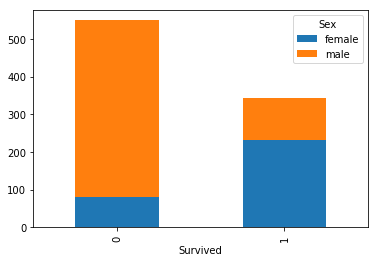

In [13]:
pd.crosstab(df['Survived'], df['Sex']).plot(kind='bar', stacked=True)

In [19]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [25]:
df['Embarked'].value_counts()

S    644
C    168
Q     77
Name: Embarked, dtype: int64

In [14]:
df['Embarked'].fillna('S', inplace=True)

In [15]:
df['Age'].fillna(df['Age'].mean(), inplace=True)

In [16]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [17]:
data_c = pd.get_dummies(df.drop(['Name', 'Ticket', 'Cabin'], axis=1))

In [18]:
data_c.shape

(891, 12)

In [48]:
data_c.to_csv('C:/Users/Manish Gupta/Desktop/data_cleaned.csv', index=False)

In [19]:
data_c.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,22.0,1,0,7.2500,0,1,0,0,1
1,2,1,1,38.0,1,0,71.2833,1,0,1,0,0
2,3,1,3,26.0,0,0,7.9250,1,0,0,0,1
3,4,1,1,35.0,1,0,53.1000,1,0,0,0,1
4,5,0,3,35.0,0,0,8.0500,0,1,0,0,1


### Segregating variables: Independent and Dependent Variables

In [20]:
#seperating independent and dependent variables
x = data_c.drop(['Survived'], axis=1)
y = data_c['Survived']
x.shape, y.shape

((891, 11), (891,))

### Splitting the data into train set and the test set

In [21]:
# Importing the train test split function
from sklearn.model_selection import train_test_split
train_x,test_x,train_y,test_y = train_test_split(x,y, random_state = 2)

### Normalising using *min_max_scaler*

In [22]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [23]:
cols = train_x.columns
cols

Index(['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female',
       'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [24]:
train_x_scaled = scaler.fit_transform(train_x)
train_x_scaled = pd.DataFrame(train_x_scaled, columns=cols)
train_x_scaled.head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0.223596,0.5,0.334089,0.000,0.0,0.025374,1.0,0.0,0.0,0.0,1.0
1,0.144944,1.0,0.631624,0.000,0.0,0.013614,0.0,1.0,0.0,0.0,1.0
2,0.101124,1.0,0.404931,0.000,0.0,0.015713,0.0,1.0,0.0,0.0,1.0
3,0.258427,0.0,0.489940,0.125,0.0,0.162932,1.0,0.0,0.0,0.0,1.0
4,0.141573,1.0,0.414836,0.000,0.0,0.015127,0.0,1.0,0.0,1.0,0.0


In [25]:
test_x_scaled = scaler.transform(test_x)
test_x_scaled = pd.DataFrame(test_x_scaled, columns=cols)
test_x_scaled.head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0.794382,0.0,0.589119,0.000,0.000000,0.051310,0.0,1.0,0.0,0.0,1.0
1,0.041573,1.0,0.291584,0.000,0.000000,0.015713,0.0,1.0,0.0,0.0,1.0
2,0.691011,0.5,0.334089,0.125,0.333333,0.126872,1.0,0.0,0.0,0.0,1.0
3,0.189888,1.0,0.390762,0.000,0.000000,0.110272,0.0,1.0,0.0,0.0,1.0
4,0.076404,1.0,0.234911,0.500,0.333333,0.015469,1.0,0.0,0.0,0.0,1.0


### Implementing Logistic Regression

In [26]:
#importing Logistic Regression and metric F1-score
from sklearn.linear_model import LogisticRegression as LogReg
from sklearn.metrics import f1_score

In [27]:
# Creating instance of Logistic Regresssion
logreg = LogReg()

# Fitting the model
logreg.fit(train_x, train_y)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='ovr', n_jobs=1,
          penalty='l2', random_state=None, solver='liblinear', tol=0.0001,
          verbose=0, warm_start=False)

### Making predictions using *predict* function

In [28]:
# Predicting over the Train
train_predict = logreg.predict(train_x)
train_predict

array([1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1,

In [29]:
# Calculating f1-score
k = f1_score(train_predict, train_y)
print('Training f1_score', k )

Training f1_score 0.734439834025


In [30]:
# Predicting over the Test Set and f1-score
test_predict = logreg.predict(test_x)
k = f1_score(test_predict, test_y)
print('Test f1_score    ', k )

Test f1_score     0.719512195122


In [31]:
#Exporting the Predicted Results as as CSV Data file
ids = test_x['PassengerId']
survivors = logreg.predict(test_x)

#set the output as a dataframe and convert to csv file named survived.csv
output = pd.DataFrame({ 'PassengerId' : ids, 'Survived': survivors })
output.to_csv('C:/Users/Manish Gupta/Desktop/survived.csv', index=False)

In [32]:
#Viewing top 5 rows of the Predictions dataset
output.head()

,PassengerId,Survived
707,708,0
37,38,0
615,616,1
169,170,0
68,69,0


# Parameters of Logistic Regression

In [100]:
# printing the coefficients
logreg.coef_

array([[  3.27951989e-04,  -9.39253818e-01,  -3.78808606e-02,
         -3.57082270e-01,  -3.40206144e-02,   2.90498795e-03,
          2.15564646e+00,  -5.32722963e-01,   7.38358222e-01,
          4.97780788e-01,   3.86784482e-01]])

### Plotting the coefficients

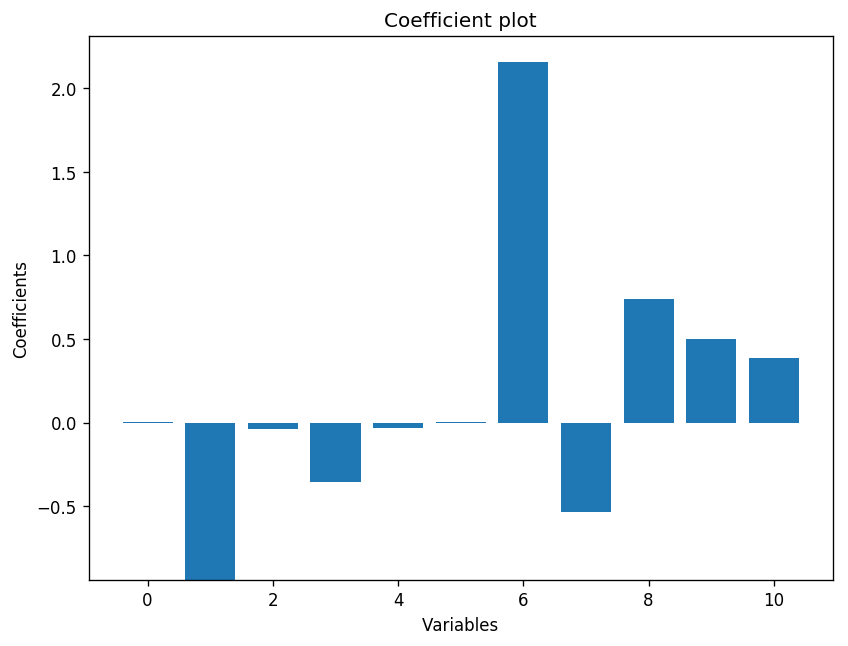

In [101]:
plt.figure(figsize=(8, 6), dpi=120, facecolor='w', edgecolor='b')
x = range(len(train_x.columns))
c = logreg.coef_.reshape(-1)
plt.bar( x, c )
plt.xlabel( "Variables")
plt.ylabel('Coefficients')
plt.title('Coefficient plot')

### Making predictions using *predict_proba* function

In [80]:
# Predicting over the Train
train_predict = logreg.predict_proba(train_x)
train_predict

array([[ 0.18526716,  0.81473284],
       [ 0.95177812,  0.04822188],
       [ 0.91576063,  0.08423937],
       ..., 
       [ 0.81674058,  0.18325942],
       [ 0.44272066,  0.55727934],
       [ 0.61219809,  0.38780191]])

In [81]:
train_preds = train_predict[:,1]  #predicting only survived passengers probability from train ds as above
train_preds 

array([ 0.81473284,  0.04822188,  0.08423937,  0.86546459,  0.09190073,
        0.91875632,  0.12945316,  0.70506435,  0.3893336 ,  0.09901361,
        0.13470587,  0.2657465 ,  0.44887345,  0.13674478,  0.80269473,
        0.07440847,  0.95607676,  0.33738596,  0.26524227,  0.57763745,
        0.78479197,  0.24760491,  0.27696558,  0.59548719,  0.63658658,
        0.16598896,  0.92872752,  0.1113054 ,  0.11197293,  0.90075822,
        0.20223235,  0.08663097,  0.097603  ,  0.06140641,  0.0516196 ,
        0.06171277,  0.63377949,  0.39692339,  0.25510469,  0.135682  ,
        0.94309408,  0.34927793,  0.05977304,  0.11133351,  0.58085874,
        0.06807454,  0.82185152,  0.14120279,  0.44554498,  0.95283704,
        0.05299723,  0.06889045,  0.48730964,  0.92111393,  0.74819717,
        0.88542642,  0.38560973,  0.96861656,  0.13834358,  0.08817612,
        0.38136632,  0.12077934,  0.0957435 ,  0.94915788,  0.07137935,
        0.19131624,  0.03109727,  0.84161049,  0.85474118,  0.07

In [82]:
for i in range(0, len(train_preds)):
  if(train_preds[i]>0.55):
    train_preds[i] = 1
  else:
    train_preds[i] = 0
  

In [83]:
# Calculating f1-score
k = f1_score(train_preds, train_y)
print('Training f1_score', k )

Training f1_score 0.735483870968


# Confusion matrix

In [84]:
from sklearn.metrics import confusion_matrix
cf= confusion_matrix(test_y, test_predict)
print(cf)

[[118  13]
 [ 33  59]]


In [85]:
from sklearn.metrics import classification_report as rep
print(rep( test_y , test_predict ))

             precision    recall  f1-score   support

          0       0.78      0.90      0.84       131
          1       0.82      0.64      0.72        92

avg / total       0.80      0.79      0.79       223



# Random Forest

** Using Random Forest to Evaluate better performance of Model if it could ober LR **

### Train Test Split

In [91]:
#seperating independent and dependent variables
x = data_c.drop(['Survived'], axis=1)
y = data_c['Survived']
x.shape, y.shape

# Importing the train test split function
from sklearn.model_selection import train_test_split
train_x,test_x,train_y,test_y = train_test_split(x,y, random_state = 101, stratify=y)

### Random Forest Model

In [92]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score   #importing Logistic Reg Model and using f1score as evaluation metrics

In [93]:
randomforest = RandomForestClassifier()
randomforest.fit(train_x, train_y)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_split=1e-07, min_samples_leaf=1,
            min_samples_split=2, min_weight_fraction_leaf=0.0,
            n_estimators=10, n_jobs=1, oob_score=False, random_state=None,
            verbose=0, warm_start=False)

**Making Predictions using Predict Function **

In [94]:
#Predicting over Train Set and f1_score on the same, f1 is HM of Precision and Recall ranging from 0 to 1
pred_train = randomforest.predict(train_x)
k = f1_score(pred_train, train_y)
print("Training F1 Score : ", k)

Training F1 Score :  0.974257425743


In [95]:
#Predicting over Test Set and f1_score on the same, f1 is HM of Precision and Recall ranging from 0 to 1
pred_test = randomforest.predict(test_x)
k = f1_score(pred_test, test_y)
print("Testing F1 Score : ", k)

Testing F1 Score :  0.653333333333


### Thus, Clearly observed that Logistic Regression model performs and works better here compared to Random Forest Model as LR is linear, suitable for Binary Classification and quicker compaed to RF and RF is overfitting here as well which is undesirable

# Thanks a Lot, Notebook Created and Analysis Done by : Manish Gupta ©